## FrozenLakePCH Environment: Basic Interaction and Wind Effects Demo

This notebook demonstrates interaction with the `FrozenLakePCH-v0` environment from CausalGym. It explores:
*   Basic environment setup (`gym.make`).
*   Using `see()` to observe the SCM's intended action and latent variables (wind).
*   Using `do(action)` to execute actions.
*   The effect of the `is_slippery` parameter on agent movement and wind interaction.
*   Rendering the environment and simulating full episodes with detailed logging.

### Setup: Imports and Global Variables

This cell imports necessary libraries (`numpy`, `gymnasium`, `causal_gym`, `matplotlib.pyplot`) and defines global variables like `SEED` for reproducibility and `USE_SPRITE_RENDERING` (though sprite rendering is less emphasized in later cells focusing on `rgb_array` for animations).

In [19]:
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

# Note: Ensure PCHs are correctly installed/imported
from causal_gym.envs import FrozenLakePCH 
# This is a test modification

### Helper Function: `show_obs`

Defines `show_obs` to display rendered environment images using `matplotlib`. This was used more in earlier versions; later cells use `display_frames` for animations.

In [20]:
SEED = 6458 # Same seed as lava example for consistency
USE_SPRITE_RENDERING = False # True for sprites (separate window), False for simple squares (in notebook)

# Helper function to display rendered environment images
def show_obs(img_arg, env, name=None): # img_arg is the result of env.render()
    img = img_arg.copy()
    
    unwrapped_scm = env.unwrapped # This is typically the SCM (FrozenLakeSCM or WindyFrozenLakeSCM)
    
    apply_texture = False
    texture_color = np.array([170, 190, 220], dtype=np.uint8) # Default icy blue for wind/slippery
    
    # Default colors/sizes if not found in SCM (e.g. older SCM version)
    # These should ideally match what the SCM's render method uses.
    original_f_color = np.array([214, 234, 248], dtype=np.uint8) # Actual COLOR_FROZEN from FrozenLakeSCM
    current_tile_size = 32 # Actual TILE_SIZE from FrozenLakeSCM

    true_base_gym_env = None

    if hasattr(unwrapped_scm, 'base_env'): # Indicates it's WindyFrozenLakeSCM
        # This is WindyFrozenLakeSCM, which wraps a FrozenLakeSCM
        actual_scm_for_render_params = unwrapped_scm.base_env
        true_base_gym_env = unwrapped_scm.base_env.env.unwrapped
        
        if unwrapped_scm.current_wind_direction != cgym.envs.windy_frozen_lake.WIND_NONE:
            apply_texture = True
    elif hasattr(unwrapped_scm, 'env'): # Indicates it's the original FrozenLakeSCM
        actual_scm_for_render_params = unwrapped_scm
        true_base_gym_env = unwrapped_scm.env.unwrapped
        
        if actual_scm_for_render_params.is_slippery:
            apply_texture = True
    else:
        print("Warning: Could not determine SCM type for texture logic.")

    if true_base_gym_env is not None:
        desc = true_base_gym_env.desc
        nrow = true_base_gym_env.nrow
        ncol = true_base_gym_env.ncol
        # Use TILE_SIZE from the SCM that does the rendering (FrozenLakeSCM)
        current_tile_size = getattr(actual_scm_for_render_params, 'TILE_SIZE', current_tile_size)
        # Use COLOR_FROZEN from the SCM for mask
        original_f_color = getattr(actual_scm_for_render_params, 'COLOR_FROZEN', original_f_color)

    if apply_texture and true_base_gym_env is not None:
        for r_idx in range(nrow):
            for c_idx in range(ncol):
                if desc[r_idx, c_idx] == b'F': 
                    tile_y_start, tile_y_end = r_idx * current_tile_size, (r_idx + 1) * current_tile_size
                    tile_x_start, tile_x_end = c_idx * current_tile_size, (c_idx + 1) * current_tile_size
                    tile_pixels_slice = img[tile_y_start:tile_y_end, tile_x_start:tile_x_end]
                    mask = np.all(tile_pixels_slice == original_f_color, axis=-1)
                    tile_pixels_slice[mask] = texture_color
    
    plt.imshow(img)
    plt.axis('off')

    if name is not None:
        plt.tight_layout()
        fig = plt.gcf()
        fig.set_size_inches(6, 6)
    plt.show()

### Scenario 1: Non-Slippery Environment (Wind Affects Actions)

Create the `FrozenLakePCH-v0` environment with `is_slippery=False`. In this mode, if wind is present in a cell, it will override the agent's intended action. A fixed seed (`SEED = 6458`) is used for reproducible results in this section.

Initial state (reset with SEED), Wind: None


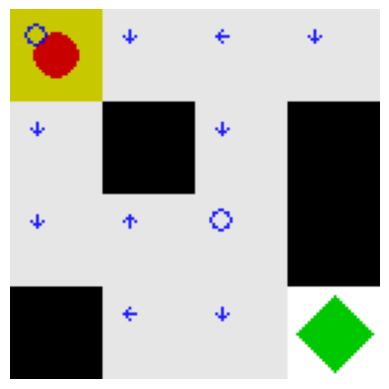

In [21]:
# Create the WindyFrozenLake environment
current_render_mode = 'human' if USE_SPRITE_RENDERING else 'rgb_array'

# Parameters for WindyFrozenLakeSCM itself (e.g., wind probabilities)
windy_params = {
    'wind_probabilities': (0.2, 0.2, 0.2, 0.2, 0.2), # Example: equal chance for all wind states (including None)
    # 'render_mode': current_render_mode # This will be passed to WindyFrozenLakeSCM constructor
}

# Use gym.make to get the PCH, as causal_gym registers its envs with Gymnasium
# The kwargs passed to make are for the PCH's SCM (WindyFrozenLakeSCM in this case)
env = gym.make(
    "causal_gym/FrozenLakePCH-v0", 
    is_slippery=False, # Changed to False to make wind affect actions
    wind_probabilities=windy_params['wind_probabilities'],
     # Pass render_mode for PCH/SCM wrapper consistency if needed by them
    render_mode=current_render_mode,
)

# Reset the environment with the seed
_, info = env.reset(seed=SEED)
print(f"Initial state (reset with SEED), Wind: {info.get('wind_direction')}")

if not USE_SPRITE_RENDERING:
    rendered_img = env.render()
    if rendered_img is not None:
        show_obs(rendered_img, env) # Pass PCH env to show_obs
else:
    env.render() # Update external window if 'human'

#### Interaction in Non-Slippery Mode (Modified Wind Interaction)

Demonstrates using `env.see()` to observe the SCM's intended action and wind, then `env.do(action)` to execute an action. 
With `is_slippery=False` and wind present in the agent's cell:
1. The wind's effect is applied first, moving the agent to an intermediate state.
2. The agent's chosen action is then applied from this intermediate state.
If no wind is present, the agent's chosen action is applied directly and deterministically. The output shows the agent's state, wind, actions (and their components if applicable), and resulting state.

State after forced action 2 (Right):
Reward: 0.16666666666666666, Done: False


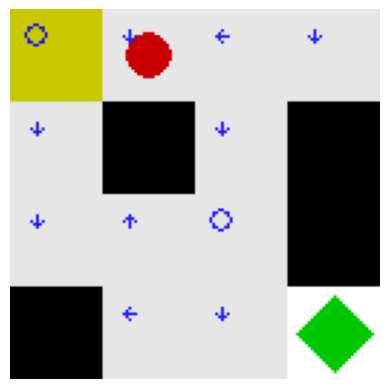

In [22]:
# Perform an observational step (see) using a fixed policy (always action 2: Right)
# Note: FrozenLakePCH.see() doesn't take bpolicy directly.
# We'll simulate by getting the default action (random in slippery mode)
# and then *showing* the result if we had *forced* action 2 (RIGHT)
# This isn't a perfect match to the lava notebook's 'see' with policy,
# but illustrates the environment state after a 'do' action.

TARGET_ACTION = 2 # Right

# Get current state before taking action
current_obs, _ = env.reset(seed=SEED) # Re-reset to ensure starting state

# Perform the 'do' action
obs, r, done, _, info = env.do(TARGET_ACTION) # Use do for a specific action

print(f"State after forced action {TARGET_ACTION} (Right):")
print(f"Reward: {r}, Done: {done}")
if not USE_SPRITE_RENDERING:
    show_obs(env.render(), env) # Pass env
else:
    env.render() # Update external window

### Scenario 2: Slippery Environment (Wind Does Not Override Actions)

Create the `FrozenLakePCH-v0` environment with `is_slippery=True` (the default for standard FrozenLake). In this mode, wind is still present and rendered, but it does not override the agent's chosen action. Instead, the chosen action has a chance of resulting in a perpendicular move due to the slippery ice. The same fixed seed (`SEED = 6458`) is used.


Initial state (reset with SEED2):


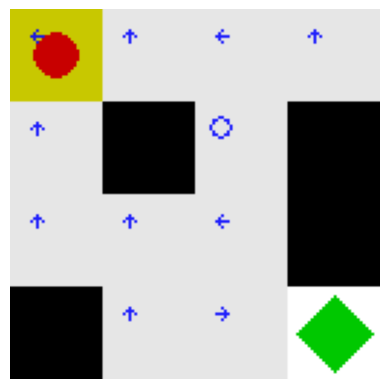

In [23]:
# Reset with a different seed
SEED2 = 1234
_, info = env.reset(seed=SEED2)
print("\nInitial state (reset with SEED2):")
if not USE_SPRITE_RENDERING:
    show_obs(env.render(), env) # Pass env
else:
    env.render() # Update external window

#### Interaction in Slippery Mode

Demonstrates `env.see()` and `env.do(action)` when `is_slippery=True`. The wind is observed but doesn't change the chosen action. The agent's movement is subject to the standard FrozenLake slipperiness (1/3 chance to go intended, 1/3 left, 1/3 right relative to intended).

State after forced action 2 (Right) from SEED2 state:
Reward: 0.16666666666666666, Done: False


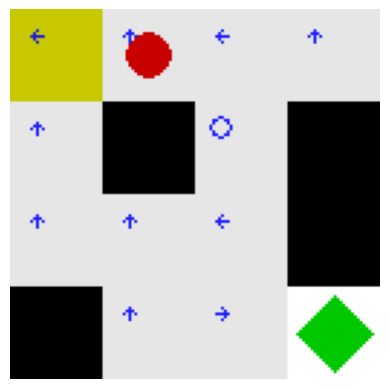

In [24]:
# Perform another 'do' action from the new state
obs, r, done, _, info = env.do(TARGET_ACTION) # Use do for a specific action

print(f"State after forced action {TARGET_ACTION} (Right) from SEED2 state:")
print(f"Reward: {r}, Done: {done}")
if not USE_SPRITE_RENDERING:
    show_obs(env.render(), env) # Pass env
else:
    env.render() # Update external window

env.close() # Close the environment when done

### Demonstrating Sequential Action: Wind First, Then Agent

The following cells illustrate the two-step process when `is_slippery=False` and wind is present:
1.  The wind's action is applied from the agent's current state to reach an intermediate state.
2.  The agent's chosen action is then applied from that intermediate state to reach the final state.

We will show two scenarios:
*   Wind moves the agent, and the agent's subsequent action is taken from the new (wind-moved) position.
*   Wind moves the agent directly into a terminal state (a hole), and the agent's action becomes irrelevant as the episode ends.

In [ ]:
# Scenario: Wind Moves Agent, Agent Acts from New Spot (Avoiding a Hole)

# --- Mappings for human-readable output ---
ACTION_MAP = {0: "LEFT ᐊ", 1: "DOWN ᐁ", 2: "RIGHT ►", 3: "UP ▲"}
WIND_MAP_NAMES = {0: "NONE", 1: "NORTH ↑", 2: "EAST →", 3: "SOUTH ↓", 4: "WEST ←"}
# WIND_NONE = 0, WIND_NORTH = 1, WIND_EAST = 2, WIND_SOUTH = 3, WIND_WEST = 4
# -----------------------------------------

# Map: S F H  (S at (0,0), F at (0,1), H at (0,2))
#      F F G  (F at (1,0), F at (1,1), G at (1,2)) - Added G
# Wind in S (0,0) is DOWN (value 3).
# Agent in S (0,0) chooses to move RIGHT (action 2).
# Expected: 
# 1. Wind (DOWN) moves agent from (0,0) to (1,0) (intermediate_state).
# 2. Agent's chosen action (RIGHT) is taken from (1,0), moving to (1,1) (final_state).

scenario_map_avoid = [
    "SFH",
    "FFG"  # Changed last F to G
]
# Wind map uses direct integer values: 0 (None), 1 (N), 2 (E), 3 (S), 4 (W)
wind_map_avoid = np.array([
    [3, 0, 0], # Wind SOUTH (Down) in S(0,0)
    [0, 0, 0]
])

print("--- Scenario: Wind Avoids Hole ---")
print(f"Test Map:\n{scenario_map_avoid}")
print(f"Wind Map:\n{wind_map_avoid}")

env_avoid = gym.make("causal_gym/FrozenLakePCH-v0", 
                     desc=scenario_map_avoid, 
                     is_slippery=False, 
                     render_mode='rgb_array')

obs_avoid, _ = env_avoid.reset(seed=10) 
env_avoid.env.wind_map = wind_map_avoid 

initial_pos_rc_avoid = env_avoid.env._to_rc(obs_avoid)
print(f"Initial State: {obs_avoid} {initial_pos_rc_avoid}")
print(f"Wind in start cell {initial_pos_rc_avoid}: {WIND_MAP_NAMES.get(env_avoid.env.wind_map[initial_pos_rc_avoid])}")

agent_action_avoid = 2 # RIGHT
print(f"Agent intends to take action: {ACTION_MAP.get(agent_action_avoid)}")

next_obs_avoid, reward_avoid, term_avoid, trunc_avoid, info_avoid = env_avoid.do(agent_action_avoid)

print("\n--- After env.do() ---")
wind_action_comp_num = info_avoid.get('wind_action_component')
agent_action_comp_num = info_avoid.get('agent_action_component')
intermediate_state_num = info_avoid.get('intermediate_state_after_wind')

if wind_action_comp_num is not None and not env_avoid.env.is_slippery and env_avoid.env.wind_map[initial_pos_rc_avoid] != 0:
    wind_name_text = WIND_MAP_NAMES.get(env_avoid.env.wind_map[initial_pos_rc_avoid])
    intermediate_pos_rc_text = env_avoid.env._to_rc(intermediate_state_num)
    print(f"  1. Wind Action ({wind_name_text}) applied from {initial_pos_rc_avoid}")
    print(f"     Resulting Intermediate State: {intermediate_state_num} {intermediate_pos_rc_text}")
    if info_avoid.get('terminated_by_wind_component', False):
        print("     TERMINATED BY WIND COMPONENT!")
    elif agent_action_comp_num is not None:
        agent_action_name_text = ACTION_MAP.get(agent_action_comp_num)
        print(f"  2. Agent's Chosen Action ({agent_action_name_text}) applied from Intermediate State {intermediate_pos_rc_text}")
else:
    final_action_taken_name = ACTION_MAP.get(agent_action_comp_num if agent_action_comp_num is not None else agent_action_avoid)
    print(f"  Single Action Executed: {final_action_taken_name}")

final_pos_rc_avoid = env_avoid.env._to_rc(next_obs_avoid)
print(f"Final New State: {next_obs_avoid} {final_pos_rc_avoid}")
print(f"Reward: {reward_avoid}")
print(f"Terminated: {term_avoid}, Truncated: {trunc_avoid}")

frames_avoid = [env_avoid.render()]
if frames_avoid:
    display_frames(frames_avoid) 
env_avoid.close()

In [ ]:
# Scenario: Wind Moves Agent into a Hole (Terminating)

# --- Mappings for human-readable output ---
ACTION_MAP = {0: "LEFT ᐊ", 1: "DOWN ᐁ", 2: "RIGHT ►", 3: "UP ▲"}
WIND_MAP_NAMES = {0: "NONE", 1: "NORTH ↑", 2: "EAST →", 3: "SOUTH ↓", 4: "WEST ←"}
# WIND_NONE = 0, WIND_NORTH = 1, WIND_EAST = 2, WIND_SOUTH = 3, WIND_WEST = 4
# -----------------------------------------

# Map: S F G  (S at (0,0), G at (0,2)) - Added G
#      H F F  (H at (1,0))
# Wind in S (0,0) is DOWN (value 3).
# Agent in S (0,0) chooses to move RIGHT (action 2).
# Expected: 
# 1. Wind (DOWN) moves agent from (0,0) to (1,0) (Hole - intermediate_state, terminal).
# 2. Agent's chosen action (RIGHT) is not effectively taken as episode ended.

scenario_map_fall = [
    "SFG", # Changed last F to G
    "HFF"
]
# Wind map uses direct integer values: 0 (None), 1 (N), 2 (E), 3 (S), 4 (W)
wind_map_fall = np.array([
    [3, 0, 0], # Wind SOUTH (Down) in S(0,0)
    [0, 0, 0]
])

print("--- Scenario: Wind Into Hole ---")
print(f"Test Map:\n{scenario_map_fall}")
print(f"Wind Map:\n{wind_map_fall}")

env_fall = gym.make("causal_gym/FrozenLakePCH-v0", 
                    desc=scenario_map_fall, 
                    is_slippery=False, 
                    render_mode='rgb_array')

obs_fall, _ = env_fall.reset(seed=20) 
env_fall.env.wind_map = wind_map_fall 

initial_pos_rc_fall = env_fall.env._to_rc(obs_fall)
print(f"Initial State: {obs_fall} {initial_pos_rc_fall}")
print(f"Wind in start cell {initial_pos_rc_fall}: {WIND_MAP_NAMES.get(env_fall.env.wind_map[initial_pos_rc_fall])}")

agent_action_fall = 2 # RIGHT
print(f"Agent intends to take action: {ACTION_MAP.get(agent_action_fall)}")

next_obs_fall, reward_fall, term_fall, trunc_fall, info_fall = env_fall.do(agent_action_fall)

print("\n--- After env.do() ---")
wind_action_comp_num = info_fall.get('wind_action_component')
agent_action_comp_num = info_fall.get('agent_action_component')
intermediate_state_num = info_fall.get('intermediate_state_after_wind')

if wind_action_comp_num is not None and not env_fall.env.is_slippery and env_fall.env.wind_map[initial_pos_rc_fall] != 0:
    wind_name_text = WIND_MAP_NAMES.get(env_fall.env.wind_map[initial_pos_rc_fall])
    intermediate_pos_rc_text = env_fall.env._to_rc(intermediate_state_num)
    print(f"  1. Wind Action ({wind_name_text}) applied from {initial_pos_rc_fall}")
    print(f"     Resulting Intermediate State: {intermediate_state_num} {intermediate_pos_rc_text}")
    if info_fall.get('terminated_by_wind_component', False):
        print("     TERMINATED BY WIND COMPONENT!")
    elif agent_action_comp_num is not None: 
        agent_action_name_text = ACTION_MAP.get(agent_action_comp_num)
        print(f"  2. Agent's Chosen Action ({agent_action_name_text}) applied from Intermediate State {intermediate_pos_rc_text}")
else:
    final_action_taken_name = ACTION_MAP.get(agent_action_comp_num if agent_action_comp_num is not None else agent_action_fall)
    print(f"  Single Action Executed: {final_action_taken_name}")

final_pos_rc_fall = env_fall.env._to_rc(next_obs_fall)
print(f"Final New State: {next_obs_fall} {final_pos_rc_fall}")
print(f"Reward: {reward_fall}")
print(f"Terminated: {term_fall}, Truncated: {trunc_fall}")

frames_fall = [env_fall.render()]
if frames_fall:
    display_frames(frames_fall)
env_fall.close()

### Helper Function: `display_frames` for Animation

Defines `display_frames` and imports necessary libraries (`matplotlib.animation.FuncAnimation`, `IPython.display.HTML`) to render a sequence of environment frames as an animation within the notebook. This is used by the final simulation cell.

In [36]:
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

def display_frames(frames, figsize=(10, 8)):
    """Displays a list of frames (RGB arrays) as an animation or sequence."""
    if not frames:
        print("No frames to display.")
        return
    
    # Check if frames are Pygame surfaces or numpy arrays
    if isinstance(frames[0], np.ndarray):
        # Simple display for a few frames, or animate if many
        if len(frames) <= 5:
            fig, axes = plt.subplots(1, len(frames), figsize=figsize)
            if len(frames) == 1:
                axes = [axes] # make it iterable
            for i, frame in enumerate(frames):
                axes[i].imshow(frame)
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()
        else: # Animation for many frames
            fig = plt.figure(figsize=figsize)
            plt.axis('off')
            plt.tight_layout()
            img_display = plt.imshow(frames[0])
            def animate(i):
                img_display.set_data(frames[i])
                return [img_display]
            
            from matplotlib.animation import FuncAnimation
            anim = FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
            from IPython.display import HTML
            plt.close(fig) # close the static plot
            display(HTML(anim.to_jshtml()))
            print("Displaying animation.")

## Episode Simulation with Detailed Step Information

The following cell simulates a single episode of the FrozenLakePCH environment. 

At the beginning of the episode, it prints:
*   The grid dimensions (e.g., 4x4).
*   Whether the environment is `is_slippery`.
*   The agent's initial state (as a raw number and as `(Row, Col)` coordinates).
*   The full `wind_map` for the episode, showing wind directions for each cell.

At each step, it then prints:
*   The agent's current state (raw number and `(Row, Col)`).
*   The wind condition in the agent's current cell (e.g., "WEST ←").
*   The action chosen by the SCM's internal policy (e.g., "UP ▲") - this is the action the agent *intends* to take.
*   Details of the action execution:
    *   If `is_slippery=False` and wind is present: It will show the wind-component action, the intermediate state after wind, and then the agent-component action from that intermediate state.
    *   Otherwise, it shows the single action taken.
*   The agent's new state after the action (raw number and `(Row, Col)`).
*   The reward received.
*   Termination and truncation status.

The environment is reset with `seed=None` for random outcomes on each run. The `is_slippery` setting in the code cell below (currently `False`) determines how wind and actions interact. An animation of the episode is displayed at the end.

--- Episode Start (Random Seed) ---
Grid Dimensions: 4x4
is_slippery: False
Initial State: 0 (Row: 0, Col: 0)
Initial Wind Map (0:None, 1:N, 2:E, 3:S, 4:W):
[[0 1 2 1]
 [1 0 4 0]
 [1 2 1 0]
 [0 4 0 0]]

--- Step 1 ---
Current State: 0 (Row: 0, Col: 0)
Wind in Current Cell (0, 0): NONE
Agent Intends to Execute Action: LEFT ᐊ (0)
  Action Executed (Standard): LEFT ᐊ (0)
Final New State: 0 (Row: 0, Col: 0)
Reward: 0.0
Terminated: False, Truncated: False

--- Step 2 ---
Current State: 0 (Row: 0, Col: 0)
Wind in Current Cell (0, 0): NONE
Agent Intends to Execute Action: RIGHT ► (2)
  1. Wind Action (NONE) applied from (0, 0)
     Resulting Intermediate State: 1 (Row: 0, Col: 1)
  2. Agent's Intended Action (RIGHT ►) applied from Intermediate State (0, 1)
Final New State: 2 (Row: 0, Col: 2)
Reward: 0.3333333333333333
Terminated: False, Truncated: False

--- Step 3 ---
Current State: 2 (Row: 0, Col: 2)
Wind in Current Cell (0, 2): EAST →
Agent Intends to Execute Action: DOWN ᐁ (1)
  Action Ex

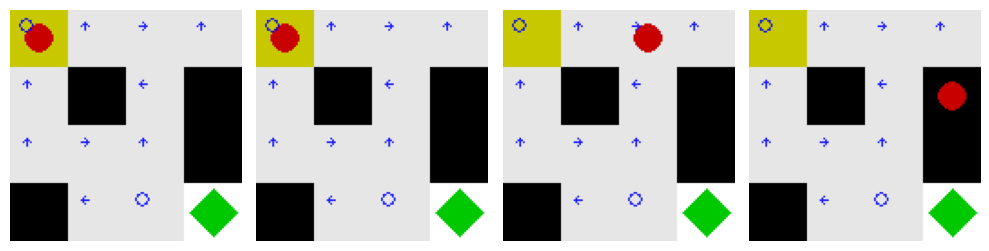

In [30]:
frames = [] # Initialize frames list

# --- Mappings for human-readable output ---
ACTION_MAP = {0: "LEFT ᐊ", 1: "DOWN ᐁ", 2: "RIGHT ►", 3: "UP ▲"}
WIND_MAP_NAMES = {0: "NONE", 1: "NORTH ↑", 2: "EAST →", 3: "SOUTH ↓", 4: "WEST ←"}
# -----------------------------------------

# Initialize with is_slippery=False for this demonstration, seed=None for randomness
env = gym.make("causal_gym/FrozenLakePCH-v0", is_slippery=False, wind_probabilities=(0.2, 0.2, 0.2, 0.2, 0.2), render_mode='rgb_array')

# Using seed=None for random initialization each time the cell is run
initial_state_from_reset, reset_info = env.reset(seed=None)
nrow, ncol = env.env.nrow, env.env.ncol # Get grid dimensions

print(f"--- Episode Start (Random Seed) ---")
print(f"Grid Dimensions: {nrow}x{ncol}")
print(f"is_slippery: {env.env.is_slippery}")
initial_pos_rc = env.env._to_rc(initial_state_from_reset)
print(f"Initial State: {initial_state_from_reset} (Row: {initial_pos_rc[0]}, Col: {initial_pos_rc[1]})")
print(f"Initial Wind Map (0:None, 1:N, 2:E, 3:S, 4:W):\n{env.env.wind_map}")

obs_render = env.render()
frames.append(obs_render)

current_state_for_loop = initial_state_from_reset

for step_counter in range(20):  # Simulate up to 20 steps
    current_pos_rc = env.env._to_rc(current_state_for_loop)
    print(f"\n--- Step {step_counter + 1} ---")
    print(f"Current State: {current_state_for_loop} (Row: {current_pos_rc[0]}, Col: {current_pos_rc[1]})")

    # This is the agent's intended action for the step, obtained via SCM's policy by env.see()
    # In a real agent, this would be agent.act(current_state_for_loop)
    agent_intended_action_num, _, _, _, _, see_info = env.see() 
    wind_in_cell_num = env.env.wind_map[current_pos_rc] 
    
    wind_name = WIND_MAP_NAMES.get(wind_in_cell_num, f"Unknown({wind_in_cell_num})")
    agent_intended_action_name = ACTION_MAP.get(agent_intended_action_num, f"Unknown({agent_intended_action_num})")

    print(f"Wind in Current Cell {current_pos_rc}: {wind_name}")
    print(f"Agent Intends to Execute Action: {agent_intended_action_name} ({agent_intended_action_num})")

    # Execute the agent's intended action in the environment
    new_obs_num, reward, term, trunc, do_info = env.do(agent_intended_action_num)
    
    # --- Detailed print based on how action was processed ---
    wind_action_component_num = do_info.get('wind_action_component')
    agent_action_component_num = do_info.get('agent_action_component')
    intermediate_state_after_wind = do_info.get('intermediate_state_after_wind')

    if wind_action_component_num is not None and not env.env.is_slippery and wind_in_cell_num != WIND_MAP_NAMES.get("NONE"): # Two-part action occurred
        wind_action_name = WIND_MAP_NAMES.get(wind_in_cell_num, f"UnknownWind({wind_in_cell_num})") # Wind name based on current cell
        intermediate_pos_rc = env.env._to_rc(intermediate_state_after_wind)
        print(f"  1. Wind Action ({wind_action_name}) applied from {current_pos_rc}")
        print(f"     Resulting Intermediate State: {intermediate_state_after_wind} (Row: {intermediate_pos_rc[0]}, Col: {intermediate_pos_rc[1]})")
        if do_info.get('terminated_by_wind_component', False):
            print("     TERMINATED BY WIND COMPONENT!")
        else:
            agent_action_name_from_intermediate = ACTION_MAP.get(agent_action_component_num, f"Unknown({agent_action_component_num})")
            print(f"  2. Agent's Intended Action ({agent_action_name_from_intermediate}) applied from Intermediate State {intermediate_pos_rc}")
    else: # Single action (slippery, or non-slippery with no wind)
        final_action_taken_name = ACTION_MAP.get(agent_action_component_num if agent_action_component_num is not None else agent_intended_action_num, "Unknown")
        print(f"  Action Executed (Standard): {final_action_taken_name} ({agent_action_component_num if agent_action_component_num is not None else agent_intended_action_num})")

    new_pos_rc = env.env._to_rc(new_obs_num)
    print(f"Final New State: {new_obs_num} (Row: {new_pos_rc[0]}, Col: {new_pos_rc[1]})")
    print(f"Reward: {reward}")
    print(f"Terminated: {term}, Truncated: {trunc}")

    obs_render = env.render()
    frames.append(obs_render)
    
    current_state_for_loop = new_obs_num

    if term or trunc:
        print(f"\n--- Episode End (Terminated: {term}, Truncated: {trunc}) ---")
        break
else:
    print("\n--- Episode End (Max steps reached) ---")

if frames:
    display_frames(frames)
